# Taller 07: Reducción de Dimensiones
## Clasificadores KNN y RNN

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn import datasets

# Cargar el dataset digits
digits = datasets.load_digits()

print("Número de muestras:", len(digits.data))
print("Número de características originales:", digits.data.shape[1])
print("Clases:", np.unique(digits.target))

Número de muestras: 1797
Número de características originales: 64
Clases: [0 1 2 3 4 5 6 7 8 9]


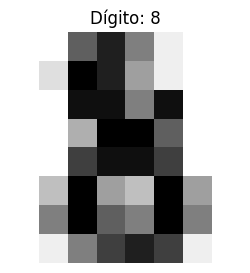

In [2]:
# Visualizar un ejemplo del dataset

plt.figure(figsize=(3, 3))
plt.imshow(
    digits.images[-1],
    cmap=plt.cm.gray_r,
    interpolation="nearest"
)
plt.title(f"Dígito: {digits.target[-1]}")
plt.axis("off")
plt.show()

## Exploración del dataset

El dataset `digits` contiene imágenes de dígitos escritos a mano
correspondientes a las clases 0 a 9.

Cada imagen tiene un tamaño de 8 × 8 píxeles, por lo que cada imagen
puede representarse mediante 64 características.

In [3]:
X = digits.data
y = digits.target

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

Dimensiones de X: (1797, 64)
Dimensiones de y: (1797,)


In [4]:
from sklearn.model_selection import train_test_split

# División 80% entrenamiento / 20% prueba
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Datos de entrenamiento:", X_train.shape)
print("Datos de prueba:", X_test.shape)

Datos de entrenamiento: (1437, 64)
Datos de prueba: (360, 64)


## Reducción de dimensiones con PCA


In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Para conocer cuántas componentes se necesitan para conservar el 95%
# de la varianza, se ajusta PCA únicamente sobre X_train.
scaler_pca = StandardScaler()
X_train_scaled = scaler_pca.fit_transform(X_train)

pca_exploracion = PCA(n_components=0.95, random_state=42)
X_train_pca = pca_exploracion.fit_transform(X_train_scaled)

print("Dimensiones originales:", X_train.shape[1])
print("Componentes seleccionados por PCA:", pca_exploracion.n_components_)
print(
    f"Varianza explicada acumulada: "
    f"{pca_exploracion.explained_variance_ratio_.sum():.4f}"
)

Dimensiones originales: 64
Componentes seleccionados por PCA: 40
Varianza explicada acumulada: 0.9516


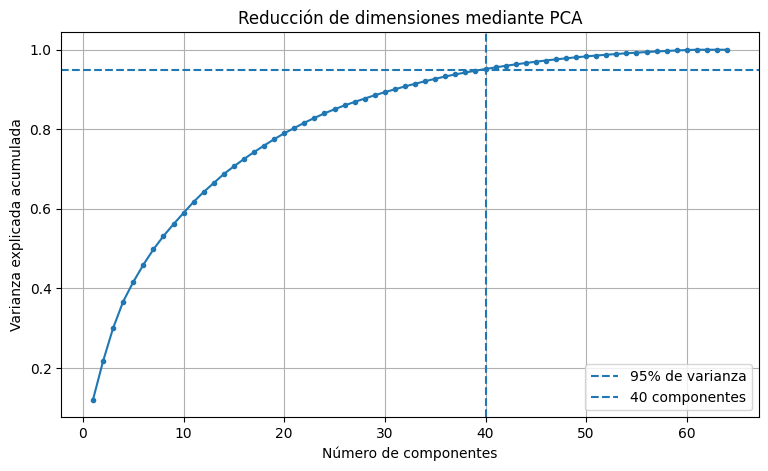

In [6]:
# Visualización de la varianza explicada acumulada

pca_completo = PCA(random_state=42)
pca_completo.fit(X_train_scaled)

varianza_acumulada = np.cumsum(
    pca_completo.explained_variance_ratio_
)

plt.figure(figsize=(9, 5))
plt.plot(
    range(1, len(varianza_acumulada) + 1),
    varianza_acumulada,
    marker="o",
    markersize=3
)
plt.axhline(0.95, linestyle="--", label="95% de varianza")
plt.axvline(
    pca_exploracion.n_components_,
    linestyle="--",
    label=f"{pca_exploracion.n_components_} componentes"
)

plt.xlabel("Número de componentes")
plt.ylabel("Varianza explicada acumulada")
plt.title("Reducción de dimensiones mediante PCA")
plt.grid(True)
plt.legend()
plt.show()

## Validación cruzada K-Fold

Para seleccionar los hiperparámetros se utilizará `K-Fold = 4`.


In [7]:
from sklearn.model_selection import KFold, cross_validate
from sklearn.metrics import precision_score, recall_score, f1_score, make_scorer

cv = KFold(
    n_splits=4,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "precision": make_scorer(
        precision_score,
        average="macro",
        zero_division=0
    ),
    "recall": make_scorer(
        recall_score,
        average="macro",
        zero_division=0
    ),
    "f1": make_scorer(
        f1_score,
        average="macro",
        zero_division=0
    )
}

print("K-Fold utilizado:", cv.n_splits)

K-Fold utilizado: 4


# Clasificador KNN


In [8]:
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA

valores_k = range(1, 21)
resultados_knn = []

for k in valores_k:
    modelo = Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=0.95, random_state=42)),
        ("knn", KNeighborsClassifier(n_neighbors=k))
    ])

    scores = cross_validate(
        modelo,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring
    )

    resultados_knn.append({
        "K": k,
        "Accuracy": scores["test_accuracy"].mean(),
        "Precision": scores["test_precision"].mean(),
        "Recall": scores["test_recall"].mean(),
        "F1": scores["test_f1"].mean()
    })

resultados_knn = pd.DataFrame(resultados_knn)

resultados_knn

,K,Accuracy,Precision,Recall,F1
0,1,0.965210,0.965069,0.966098,0.964904
1,2,0.960349,0.961978,0.961278,0.959392
2,3,0.967301,0.968071,0.967743,0.966728
3,4,0.968696,0.969881,0.968427,0.967824
4,5,0.969388,0.970252,0.969490,0.968939
5,6,0.966611,0.967814,0.966909,0.966080
6,7,0.965212,0.966340,0.965159,0.964682
7,8,0.962430,0.962926,0.962669,0.961709
8,9,0.963821,0.964478,0.963910,0.963071
9,10,0.963127,0.963560,0.963300,0.962352


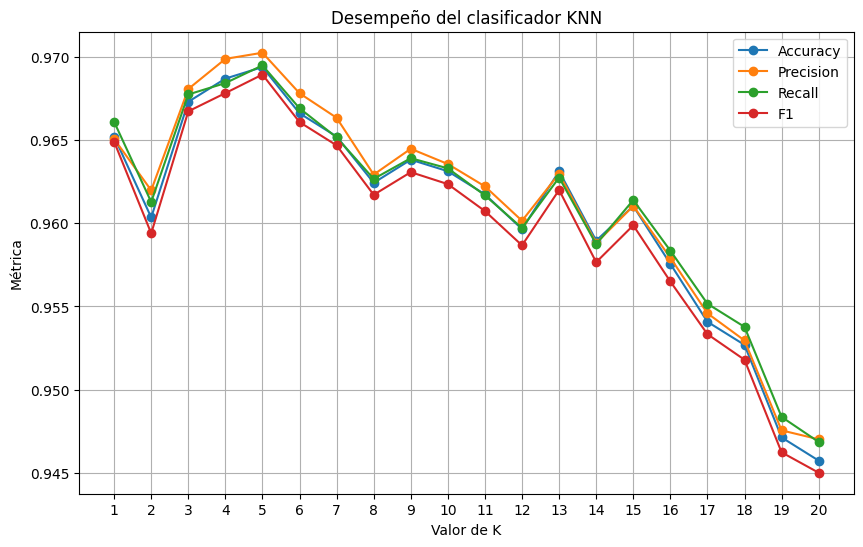

In [9]:
plt.figure(figsize=(10, 6))

plt.plot(resultados_knn["K"], resultados_knn["Accuracy"],
         marker="o", label="Accuracy")
plt.plot(resultados_knn["K"], resultados_knn["Precision"],
         marker="o", label="Precision")
plt.plot(resultados_knn["K"], resultados_knn["Recall"],
         marker="o", label="Recall")
plt.plot(resultados_knn["K"], resultados_knn["F1"],
         marker="o", label="F1")

plt.xlabel("Valor de K")
plt.ylabel("Métrica")
plt.title("Desempeño del clasificador KNN")
plt.xticks(list(valores_k))
plt.grid(True)
plt.legend()
plt.show()

In [10]:
# Selección del mejor K según F1-score promedio
mejor_k = int(resultados_knn.loc[
    resultados_knn["F1"].idxmax(),
    "K"
])

mejores_metricas_knn = resultados_knn[
    resultados_knn["K"] == mejor_k
]

print("Mejor valor de K:", mejor_k)
print("\nMétricas del mejor K:")
print(mejores_metricas_knn.to_string(index=False))

Mejor valor de K: 5

Métricas del mejor K:
 K  Accuracy  Precision  Recall       F1
 5  0.969388   0.970252 0.96949 0.968939


## Modelo KNN definitivo


In [11]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

knn_final = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.95, random_state=42)),
    ("knn", KNeighborsClassifier(n_neighbors=mejor_k))
])

knn_final.fit(X_train, y_train)
y_pred_knn = knn_final.predict(X_test)

accuracy_knn = accuracy_score(y_test, y_pred_knn)
precision_knn = precision_score(
    y_test, y_pred_knn, average="macro", zero_division=0
)
recall_knn = recall_score(
    y_test, y_pred_knn, average="macro", zero_division=0
)
f1_knn = f1_score(
    y_test, y_pred_knn, average="macro", zero_division=0
)

print("Resultados KNN en el conjunto de prueba")
print("-----------------------------------------")
print(f"Accuracy : {accuracy_knn:.4f}")
print(f"Precision: {precision_knn:.4f}")
print(f"Recall   : {recall_knn:.4f}")
print(f"F1-score : {f1_knn:.4f}")

print("\nReporte de clasificación:")
print(classification_report(
    y_test,
    y_pred_knn,
    zero_division=0
))

Resultados KNN en el conjunto de prueba
-----------------------------------------
Accuracy : 0.9722
Precision: 0.9731
Recall   : 0.9721
F1-score : 0.9720

Reporte de clasificación:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.95      1.00      0.97        36
           2       0.95      1.00      0.97        35
           3       1.00      0.97      0.99        37
           4       1.00      0.97      0.99        36
           5       0.95      0.97      0.96        37
           6       0.97      1.00      0.99        36
           7       0.95      0.97      0.96        36
           8       1.00      0.89      0.94        35
           9       0.97      0.94      0.96        36

    accuracy                           0.97       360
   macro avg       0.97      0.97      0.97       360
weighted avg       0.97      0.97      0.97       360



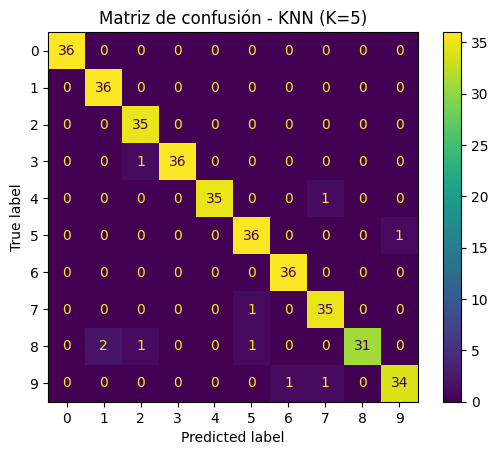

In [12]:
cm_knn = confusion_matrix(y_test, y_pred_knn)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_knn,
    display_labels=digits.target_names
)

disp.plot()
plt.title(f"Matriz de confusión - KNN (K={mejor_k})")
plt.show()

# Clasificador RNN


In [13]:
from sklearn.neighbors import RadiusNeighborsClassifier

valores_r = np.arange(2.0, 10.1, 0.5)
resultados_rnn = []

for r in valores_r:
    modelo = Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=0.95, random_state=42)),
        ("rnn", RadiusNeighborsClassifier(
            radius=float(r),
            outlier_label="most_frequent"
        ))
    ])

    scores = cross_validate(
        modelo,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring
    )

    resultados_rnn.append({
        "R": r,
        "Accuracy": scores["test_accuracy"].mean(),
        "Precision": scores["test_precision"].mean(),
        "Recall": scores["test_recall"].mean(),
        "F1": scores["test_f1"].mean()
    })

resultados_rnn = pd.DataFrame(resultados_rnn)

resultados_rnn

,R,Accuracy,Precision,Recall,F1
0,2.0,0.121098,0.457949,0.143526,0.091056
1,2.5,0.243607,0.809133,0.263947,0.266429
2,3.0,0.428702,0.911733,0.445600,0.486605
3,3.5,0.654163,0.916537,0.664435,0.708250
4,4.0,0.803076,0.919719,0.810191,0.830648
5,4.5,0.885887,0.930727,0.889558,0.894032
6,5.0,0.919278,0.937826,0.921310,0.920593
7,5.5,0.926938,0.937407,0.928987,0.927186
8,6.0,0.935287,0.939574,0.936715,0.934481
9,6.5,0.918584,0.923122,0.920310,0.917653


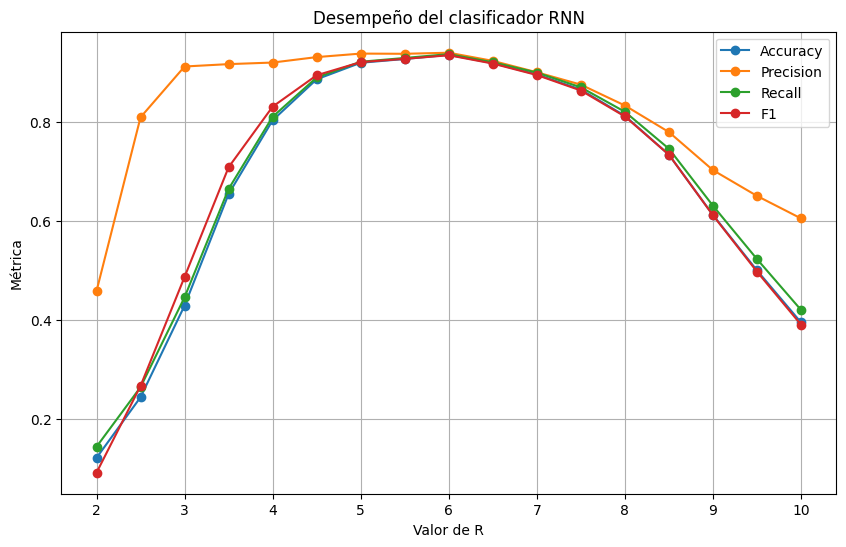

In [14]:
plt.figure(figsize=(10, 6))

plt.plot(resultados_rnn["R"], resultados_rnn["Accuracy"],
         marker="o", label="Accuracy")
plt.plot(resultados_rnn["R"], resultados_rnn["Precision"],
         marker="o", label="Precision")
plt.plot(resultados_rnn["R"], resultados_rnn["Recall"],
         marker="o", label="Recall")
plt.plot(resultados_rnn["R"], resultados_rnn["F1"],
         marker="o", label="F1")

plt.xlabel("Valor de R")
plt.ylabel("Métrica")
plt.title("Desempeño del clasificador RNN")
plt.grid(True)
plt.legend()
plt.show()

In [15]:
# Selección del mejor R según F1-score promedio
mejor_r = float(resultados_rnn.loc[
    resultados_rnn["F1"].idxmax(),
    "R"
])

mejores_metricas_rnn = resultados_rnn[
    resultados_rnn["R"] == mejor_r
]

print("Mejor valor de R:", mejor_r)
print("\nMétricas del mejor R:")
print(mejores_metricas_rnn.to_string(index=False))

Mejor valor de R: 6.0

Métricas del mejor R:
  R  Accuracy  Precision   Recall       F1
6.0  0.935287   0.939574 0.936715 0.934481


## Modelo RNN definitivo



In [16]:
rnn_final = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.95, random_state=42)),
    ("rnn", RadiusNeighborsClassifier(
        radius=mejor_r,
        outlier_label="most_frequent"
    ))
])

rnn_final.fit(X_train, y_train)
y_pred_rnn = rnn_final.predict(X_test)

accuracy_rnn = accuracy_score(y_test, y_pred_rnn)
precision_rnn = precision_score(
    y_test, y_pred_rnn, average="macro", zero_division=0
)
recall_rnn = recall_score(
    y_test, y_pred_rnn, average="macro", zero_division=0
)
f1_rnn = f1_score(
    y_test, y_pred_rnn, average="macro", zero_division=0
)

print("Resultados RNN en el conjunto de prueba")
print("-----------------------------------------")
print(f"Accuracy : {accuracy_rnn:.4f}")
print(f"Precision: {precision_rnn:.4f}")
print(f"Recall   : {recall_rnn:.4f}")
print(f"F1-score : {f1_rnn:.4f}")

print("\nReporte de clasificación:")
print(classification_report(
    y_test,
    y_pred_rnn,
    zero_division=0
))

Resultados RNN en el conjunto de prueba
-----------------------------------------
Accuracy : 0.9361
Precision: 0.9482
Recall   : 0.9355
F1-score : 0.9374

Reporte de clasificación:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.69      1.00      0.82        36
           2       1.00      0.97      0.99        35
           3       0.97      1.00      0.99        37
           4       1.00      0.89      0.94        36
           5       1.00      0.95      0.97        37
           6       1.00      0.94      0.97        36
           7       0.95      0.97      0.96        36
           8       0.93      0.74      0.83        35
           9       0.94      0.89      0.91        36

    accuracy                           0.94       360
   macro avg       0.95      0.94      0.94       360
weighted avg       0.95      0.94      0.94       360



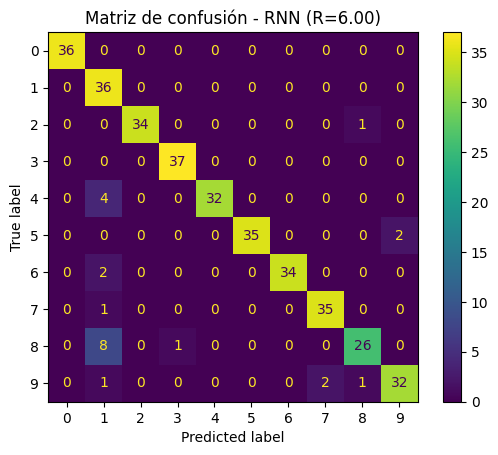

In [17]:
cm_rnn = confusion_matrix(y_test, y_pred_rnn)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rnn,
    display_labels=digits.target_names
)

disp.plot()
plt.title(f"Matriz de confusión - RNN (R={mejor_r:.2f})")
plt.show()

# Comparación final

La siguiente tabla presenta el desempeño de los dos clasificadores sobre
el conjunto de prueba. El hiperparámetro mostrado fue seleccionado
previamente mediante validación cruzada de 4 folds.

In [18]:
comparacion = pd.DataFrame({
    "Modelo": ["KNN", "RNN"],
    "Hiperparámetro": [
        f"K = {mejor_k}",
        f"R = {mejor_r:.2f}"
    ],
    "Accuracy": [
        accuracy_knn,
        accuracy_rnn
    ],
    "Precision": [
        precision_knn,
        precision_rnn
    ],
    "Recall": [
        recall_knn,
        recall_rnn
    ],
    "F1-score": [
        f1_knn,
        f1_rnn
    ]
})

comparacion

,Modelo,Hiperparámetro,Accuracy,Precision,Recall,F1-score
0,KNN,K = 5,0.972222,0.973103,0.972055,0.971976
1,RNN,R = 6.00,0.936111,0.948169,0.935468,0.937377


In [19]:
print("RESUMEN FINAL DEL TALLER")
print("=" * 60)
print(f"Dimensiones originales: {X.shape[1]}")
print(f"Componentes PCA: {pca_exploracion.n_components_}")
print(
    f"Varianza conservada: "
    f"{pca_exploracion.explained_variance_ratio_.sum():.4f}"
)
print(f"Mejor K para KNN: {mejor_k}")
print(f"Mejor R para RNN: {mejor_r:.2f}")

print("\nResultados sobre el conjunto de prueba:")
print(f"KNN -> Accuracy={accuracy_knn:.4f}, F1={f1_knn:.4f}")
print(f"RNN -> Accuracy={accuracy_rnn:.4f}, F1={f1_rnn:.4f}")

RESUMEN FINAL DEL TALLER
Dimensiones originales: 64
Componentes PCA: 40
Varianza conservada: 0.9516
Mejor K para KNN: 5
Mejor R para RNN: 6.00

Resultados sobre el conjunto de prueba:
KNN -> Accuracy=0.9722, F1=0.9720
RNN -> Accuracy=0.9361, F1=0.9374
